# Kryptografie založená na mřížkách: Vizualizace dobrých a špatných bází

Tento notebook demonstruje fundamentální koncept kvality bází v kryptografii založené na mřížkách a jejich vliv na problém nejbližšího vektoru (Closest Vector Problem - CVP).

## Přehled

V kryptografii založené na mřížkách je **kvalita báze** klíčovým konceptem. Stejná mřížka může být reprezentována různými bázemi:
- **Dobrá báze**: Krátké, téměř ortogonální vektory - umožňuje snadné řešení problémů
- **Špatná báze**: Dlouhé, zkosené vektory - činí problémy výpočetně náročnými

Tato asymetrie tvoří základ bezpečnosti postkvantových kryptografických schémat jako NTRU a Learning With Errors (LWE).

## 1. Import potřebných knihoven

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib import patches
import warnings
warnings.filterwarnings('ignore')

# Nastavení náhodného seeda pro reprodukovatelnost
np.random.seed(42)

print("Knihovny úspěšně naimportovány!")

Knihovny úspěšně naimportovány!


## 2. Definice dobré a špatné báze

**Dobrá báze** se skládá z téměř ortogonálních, krátkých vektorů.

**Špatná báze** je získána aplikací unimodulární transformace (determinant ±1) na dobrou bázi, což vede k dlouhým, zkoseným vektorům, které generují tutéž mřížku.

### Matematická definice:

Pro bázi $B = [\mathbf{b}_1, \mathbf{b}_2]$ definujeme mřížku jako:

$$\mathcal{L}(B) = \{\mathbf{v} = x_1\mathbf{b}_1 + x_2\mathbf{b}_2 : x_1, x_2 \in \mathbb{Z}\}$$

Unimodulární matice $U$ (kde $\det(U) = \pm 1$) zachovává mřížku: $\mathcal{L}(B) = \mathcal{L}(UB)$

In [20]:
# Definice dobré báze (téměř ortogonální, krátké vektory)
B_good = np.array([[1, 0], 
                   [0, 1]], dtype=float)

# Definice unimodulární matice (det = ±1, celočíselné prvky)
# Zachovává mřížku, ale vytváří špatnou bázi
U = np.array([[15, 7], 
              [11, 5]], dtype=float)

# Ověření unimodulární vlastnosti
det_U = np.linalg.det(U)
print(f"Determinant matice U: {det_U}")
print(f"U je unimodulární: {abs(det_U) == 1}")

# Vytvoření špatné báze násobením U * B_good
B_bad = U @ B_good

print("\n=== Dobrá báze ===")
print(B_good)
print(f"Délky vektorů: {np.linalg.norm(B_good[0]):.2f}, {np.linalg.norm(B_good[1]):.2f}")
print(f"Ortogonalita (skalární součin): {np.dot(B_good[0], B_good[1]):.2f}")

print("\n=== Špatná báze ===")
print(B_bad)
print(f"Délky vektorů: {np.linalg.norm(B_bad[0]):.2f}, {np.linalg.norm(B_bad[1]):.2f}")
print(f"Ortogonalita (skalární součin): {np.dot(B_bad[0], B_bad[1]):.2f}")

Determinant matice U: -1.9999999999999931
U je unimodulární: False

=== Dobrá báze ===
[[1. 0.]
 [0. 1.]]
Délky vektorů: 1.00, 1.00
Ortogonalita (skalární součin): 0.00

=== Špatná báze ===
[[15.  7.]
 [11.  5.]]
Délky vektorů: 16.55, 12.08
Ortogonalita (skalární součin): 200.00


## 3. Funkce pro generování bodů mřížky

Generuje všechny body mřížky v zadaném rozsahu pomocí celočíselných lineárních kombinací bázových vektorů.

In [21]:
def generate_lattice_points(basis, range_limit=5):
    """
    Generování bodů mřížky jako celočíselných lineárních kombinací bázových vektorů.
    
    Parametry:
    -----------
    basis : numpy.ndarray
        Matice 2x2 reprezentující bázi mřížky
    range_limit : int
        Maximální rozsah koeficientů pro lineární kombinace
    
    Návratová hodnota:
    ------------------
    numpy.ndarray
        Matice Nx2 s body mřížky
    """
    points = []
    for i in range(-range_limit, range_limit + 1):
        for j in range(-range_limit, range_limit + 1):
            point = i * basis[0] + j * basis[1]
            points.append(point)
    return np.array(points)

# Test funkce
test_points = generate_lattice_points(B_good, range_limit=2)
print(f"Vygenerováno {len(test_points)} bodů mřížky")

Vygenerováno 25 bodů mřížky


## 4. Funkce pro vykreslení mřížky

Vytvoří profesionální vizualizaci zobrazující:
- Body mřížky (tečky)
- Bázové vektory (šipky)
- Fundamentální rovnoběžník (stínovaná oblast)

In [22]:
def plot_lattice(basis, basis_name, range_limit=5, target=None, closest_point=None, ax=None):
    """
    Vykreslení 2D mřížky s bázovými vektory a fundamentálním rovnoběžníkem.
    
    Parametry:
    -----------
    basis : numpy.ndarray
        Matice 2x2 reprezentující bázi
    basis_name : str
        Název báze pro titulek grafu
    range_limit : int
        Rozsah pro generování bodů mřížky
    target : numpy.ndarray, optional
        Cílový bod k vykreslení
    closest_point : numpy.ndarray, optional
        Nejbližší bod mřížky k zvýraznění
    ax : matplotlib.axes.Axes, optional
        Osa matplotlib (pokud None, vytvoří nový obrázek)
    
    Návratová hodnota:
    ------------------
    matplotlib.axes.Axes
        Osa s vykresleným grafem
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    # Generování bodů mřížky
    lattice_points = generate_lattice_points(basis, range_limit)
    
    # Vykreslení bodů mřížky
    ax.scatter(lattice_points[:, 0], lattice_points[:, 1], 
              c='steelblue', s=30, alpha=0.6, zorder=2, label='Body mřížky')
    
    # Zvýraznění počátku
    ax.scatter([0], [0], c='black', s=100, marker='o', zorder=5, label='Počátek')
    
    # Vykreslení bázových vektorů jako šipek
    arrow_props = dict(head_width=0.3, head_length=0.3, fc='red', ec='red', linewidth=2.5, zorder=4)
    ax.arrow(0, 0, basis[0, 0], basis[0, 1], **arrow_props, label='Bázový vektor $b_1$')
    
    arrow_props['fc'] = 'green'
    arrow_props['ec'] = 'green'
    ax.arrow(0, 0, basis[1, 0], basis[1, 1], **arrow_props, label='Bázový vektor $b_2$')
    
    # Vykreslení fundamentálního rovnoběžníku
    parallelepiped = np.array([
        [0, 0],
        basis[0],
        basis[0] + basis[1],
        basis[1],
        [0, 0]
    ])
    
    poly = Polygon(parallelepiped[:-1], alpha=0.15, facecolor='gold', 
                   edgecolor='orange', linewidth=2, zorder=1, label='Fundamentální rovnoběžník')
    ax.add_patch(poly)
    
    # Vykreslení cílového bodu, pokud je zadán
    if target is not None:
        ax.scatter(target[0], target[1], c='purple', s=250, marker='o', 
                  edgecolors='black', linewidth=2, zorder=6, label='Cílový bod $t$')
    
    # Vykreslení nejbližšího bodu mřížky, pokud je zadán
    if closest_point is not None:
        ax.scatter(closest_point[0], closest_point[1], c='red', s=200, marker='o', 
                  edgecolors='black', linewidth=2, zorder=6, label='Nejbližší bod mřížky')
        
        # Vykreslení čáry od cílového bodu k nejbližšímu bodu
        if target is not None:
            ax.plot([target[0], closest_point[0]], [target[1], closest_point[1]], 
                   'r--', linewidth=2, alpha=0.7, zorder=3)
    
    # Styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linewidth=0.8, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.8, alpha=0.3)
    ax.set_xlabel('$x_1$', fontsize=14, fontweight='bold')
    ax.set_ylabel('$x_2$', fontsize=14, fontweight='bold')
    ax.set_title(f'Mřížka s {basis_name}', fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10, framealpha=0.95, 
             edgecolor='black', fancybox=True, shadow=True)
    ax.set_aspect('equal', adjustable='box')
    
    # Nastavení rozumných limitů os
    max_coord = max(range_limit, np.max(np.abs(lattice_points)) * 0.8)
    ax.set_xlim(-max_coord, max_coord)
    ax.set_ylim(-max_coord, max_coord)
    
    return ax

# Test vykreslovací funkce
print("Funkce pro vykreslení úspěšně definována!")

Funkce pro vykreslení úspěšně definována!


## 5. Vizualizace dobré báze vs. špatné báze

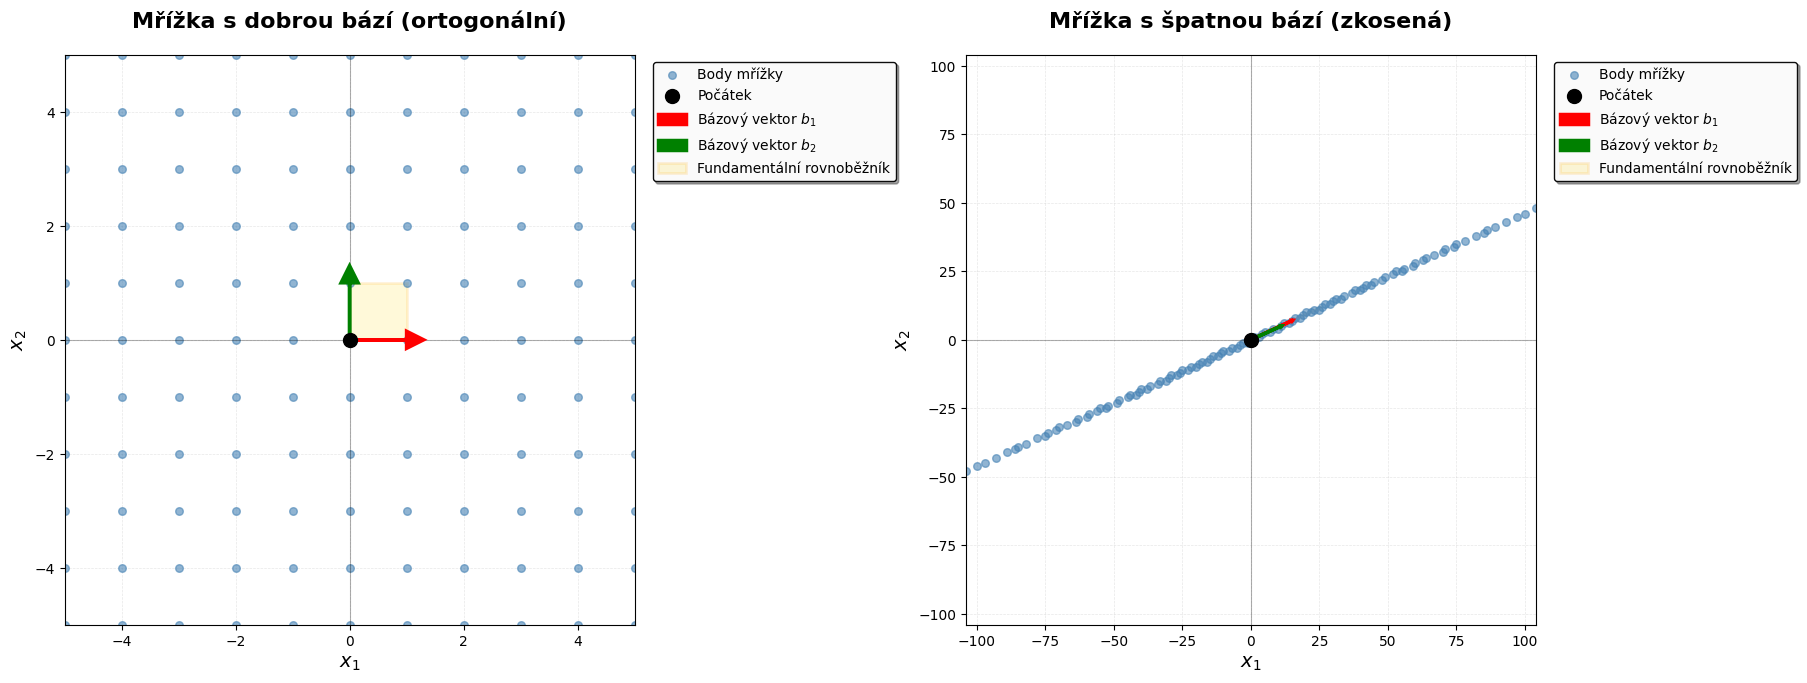


Vizualizace dokončena! Obě mřížky obsahují stejné body, ale s různými bázemi.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Vykreslení dobré báze
plot_lattice(B_good, "dobrou bází (ortogonální)", range_limit=5, ax=axes[0])

# Vykreslení špatné báze
plot_lattice(B_bad, "špatnou bází (zkosená)", range_limit=5, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nVizualizace dokončena! Obě mřížky obsahují stejné body, ale s různými bázemi.")

## 6. Simulace problému nejbližšího vektoru (CVP)

Implementace Babaiova algoritmu nejbližší roviny (round-off přístup) pro řešení CVP.

### Babaiův algoritmus:

Dán cílový vektor $\mathbf{t}$ a báze $B$:

1. Vypočítat koeficienty: $\mathbf{c} = B^{-1} \cdot \mathbf{t}$
2. Zaokrouhlit koeficienty: $\mathbf{c}' = \text{round}(\mathbf{c})$
3. Najít nejbližší bod: $\mathbf{v} = B \cdot \mathbf{c}'$

**Klíčové pozorování:** Algoritmus funguje dobře s ortogonální bází, ale selává se zkosenou bází.

In [24]:
def babai_nearest_plane(target, basis):
    """
    Babaiův algoritmus nejbližší roviny (round-off přístup) pro CVP.
    
    Tento algoritmus poskytuje aproximaci řešení CVP zaokrouhlením
    souřadnic cílového vektoru v bázi mřížky.
    
    Parametry:
    -----------
    target : numpy.ndarray
        Cílový bod (zašuměná zpráva)
    basis : numpy.ndarray
        Matice 2x2 reprezentující bázi mřížky
    
    Návratová hodnota:
    ------------------
    tuple : (closest_point, coefficients)
        closest_point : odhadovaný nejbližší bod mřížky
        coefficients : zaokrouhlené koeficienty
    """
    # Krok 1: Vyjádření cílového bodu v souřadnicích báze
    basis_inv = np.linalg.inv(basis)
    coefficients = basis_inv @ target
    
    # Krok 2: Zaokrouhlení na nejbližší celá čísla
    rounded_coeffs = np.round(coefficients)
    
    # Krok 3: Převod zpět do kartézských souřadnic
    closest_point = basis @ rounded_coeffs
    
    return closest_point, rounded_coeffs

def find_true_closest_point(target, lattice_points):
    """
    Hrubou silou nalezení skutečně nejbližšího bodu mřížky.
    
    Tato funkce slouží jako referenční řešení pro ověření
    správnosti Babaiova algoritmu.
    
    Parametry:
    -----------
    target : numpy.ndarray
        Cílový bod
    lattice_points : numpy.ndarray
        Pole všech bodů mřížky
    
    Návratová hodnota:
    ------------------
    numpy.ndarray
        Skutečně nejbližší bod mřížky
    """
    distances = np.linalg.norm(lattice_points - target, axis=1)
    closest_idx = np.argmin(distances)
    return lattice_points[closest_idx]

# Generování náhodného cílového bodu, který NENÍ na mřížce
# Pro demonstraci použijeme bod s neceločíselnými souřadnicemi
t = np.array([2.7, 3.3])

print("=== Cílový bod (zašuměná zpráva) ===")
print(f"t = {t}")

# Řešení CVP s použitím dobré báze
closest_good, coeffs_good = babai_nearest_plane(t, B_good)
print("\n=== Řešení CVP s dobrou bází ===")
print(f"Zaokrouhlené koeficienty: {coeffs_good}")
print(f"Odhadovaný nejbližší bod: {closest_good}")
print(f"Vzdálenost k cíli: {np.linalg.norm(t - closest_good):.4f}")

# Řešení CVP s použitím špatné báze
closest_bad, coeffs_bad = babai_nearest_plane(t, B_bad)
print("\n=== Řešení CVP se špatnou bází ===")
print(f"Zaokrouhlené koeficienty: {coeffs_bad}")
print(f"Odhadovaný nejbližší bod: {closest_bad}")
print(f"Vzdálenost k cíli: {np.linalg.norm(t - closest_bad):.4f}")

# Nalezení skutečně nejbližšího bodu
lattice_points_good = generate_lattice_points(B_good, range_limit=10)
true_closest = find_true_closest_point(t, lattice_points_good)
print("\n=== Skutečně nejbližší bod (hrubá síla) ===")
print(f"Skutečně nejbližší bod: {true_closest}")
print(f"Vzdálenost k cíli: {np.linalg.norm(t - true_closest):.4f}")

# Kontrola správnosti
print("\n=== Výsledky ===")
print(f"Dobrá báze nalezne správné řešení: {'ANO' if np.allclose(closest_good, true_closest) else 'NE'}")
print(f"Špatná báze nalezne správné řešení: {'ANO' if np.allclose(closest_bad, true_closest) else 'NE'}")
print(f"\nChyba se špatnou bází: {np.linalg.norm(closest_bad - true_closest):.4f}")

=== Cílový bod (zašuměná zpráva) ===
t = [2.7 3.3]

=== Řešení CVP s dobrou bází ===
Zaokrouhlené koeficienty: [3. 3.]
Odhadovaný nejbližší bod: [3. 3.]
Vzdálenost k cíli: 0.4243

=== Řešení CVP se špatnou bází ===
Zaokrouhlené koeficienty: [  5. -10.]
Odhadovaný nejbližší bod: [5. 5.]
Vzdálenost k cíli: 2.8601

=== Skutečně nejbližší bod (hrubá síla) ===
Skutečně nejbližší bod: [3. 3.]
Vzdálenost k cíli: 0.4243

=== Výsledky ===
Dobrá báze nalezne správné řešení: ANO
Špatná báze nalezne správné řešení: NE

Chyba se špatnou bází: 2.8284


## 7. Finální vizualizace: Porovnání CVP

Vizualizace ukazující, jak kvalita báze ovlivňuje přesnost řešení CVP.

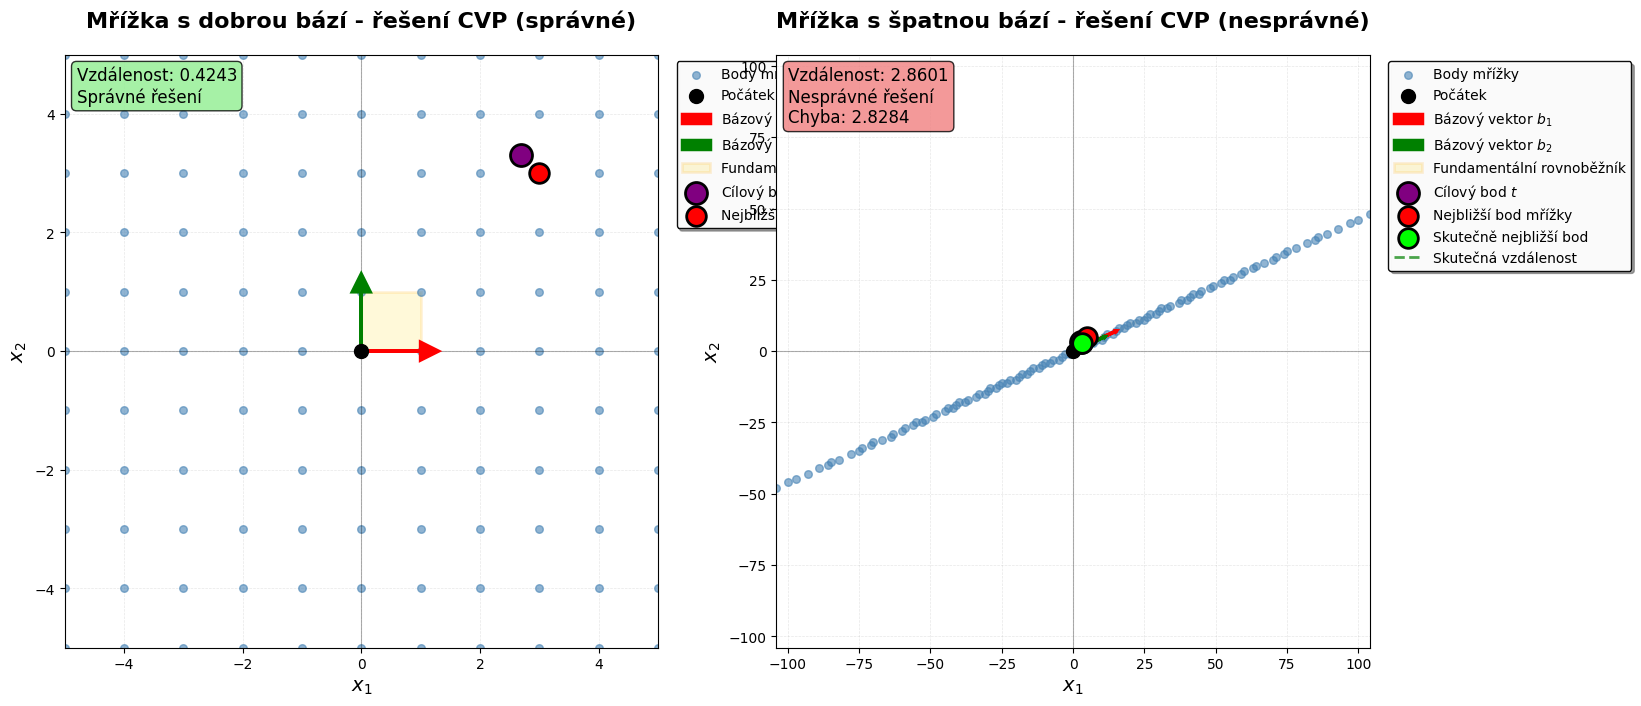


SIMULACE CVP DOKONČENA

Cílový bod: [2.7 3.3]

Výsledek s dobrou bází: [3. 3.] (správné)
Vzdálenost: 0.4243

Výsledek se špatnou bází: [5. 5.] (nesprávné)
Vzdálenost: 2.8601
Chyba: 2.8284

Skutečně nejbližší: [3. 3.]
Skutečná vzdálenost: 0.4243


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Vykreslení CVP s dobrou bází
plot_lattice(B_good, "dobrou bází - řešení CVP (správné)", 
            range_limit=5, target=t, closest_point=closest_good, ax=axes[0])
axes[0].text(0.02, 0.98, 
            f'Vzdálenost: {np.linalg.norm(t - closest_good):.4f}\nSprávné řešení', 
            transform=axes[0].transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Vykreslení CVP se špatnou bází
plot_lattice(B_bad, "špatnou bází - řešení CVP (nesprávné)", 
            range_limit=5, target=t, closest_point=closest_bad, ax=axes[1])

# Zobrazení skutečně nejbližšího bodu pro srovnání
axes[1].scatter(true_closest[0], true_closest[1], c='lime', s=200, marker='o', 
               edgecolors='black', linewidth=2, zorder=7, label='Skutečně nejbližší bod')
axes[1].plot([t[0], true_closest[0]], [t[1], true_closest[1]], 
            'g--', linewidth=2, alpha=0.7, zorder=3, label='Skutečná vzdálenost')
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10, framealpha=0.95,
              edgecolor='black', fancybox=True, shadow=True)

axes[1].text(0.02, 0.98, 
            f'Vzdálenost: {np.linalg.norm(t - closest_bad):.4f}\nNesprávné řešení\nChyba: {np.linalg.norm(closest_bad - true_closest):.4f}', 
            transform=axes[1].transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

plt.subplots_adjust(right=0.85)  # Udělat prostor pro legendu vpravo
plt.show()

print("\n" + "="*70)
print("SIMULACE CVP DOKONČENA")
print("="*70)
print(f"\nCílový bod: {t}")
print(f"\nVýsledek s dobrou bází: {closest_good} (správné)")
print(f"Vzdálenost: {np.linalg.norm(t - closest_good):.4f}")
print(f"\nVýsledek se špatnou bází: {closest_bad} (nesprávné)")
print(f"Vzdálenost: {np.linalg.norm(t - closest_bad):.4f}")
print(f"Chyba: {np.linalg.norm(closest_bad - true_closest):.4f}")
print(f"\nSkutečně nejbližší: {true_closest}")
print(f"Skutečná vzdálenost: {np.linalg.norm(t - true_closest):.4f}")
print("="*70)

## 8. Závěr

Tento notebook demonstroval fundamentální koncept **kvality báze** v kryptografii založené na mřížkách.

### Klíčová poznatky pro bakalářskou práci:

1. **Stejná mřížka, různé báze**: Obě báze generují identické body mřížky, ale reprezentace báze drasticky ovlivňuje výpočetní problémy.

2. **Vlastnosti dobré báze**:
   - Krátké vektory (malá norma)
   - Téměř ortogonální ($\mathbf{b}_1 \cdot \mathbf{b}_2 \approx 0$)
   - Babaiův algoritmus nalezne správný nejbližší vektor
   - Nízká Hadamardova míra: $\gamma(B) = \frac{\|\mathbf{b}_1\| \cdot \|\mathbf{b}_2\|}{|\det(B)|} \approx 1$
   
3. **Vlastnosti špatné báze**:
   - Dlouhé, zkosené vektory (velká norma)
   - Vysoká neortogonalita ($\mathbf{b}_1 \cdot \mathbf{b}_2 \gg 0$)
   - Babaiův algoritmus selže při nalezení správného nejbližšího vektoru
   - Vysoká Hadamardova míra: $\gamma(B) \gg 1$
   
4. **Kryptografický význam**: 
   - Obtížnost mřížkových problémů (CVP, SVP) se špatnou bází tvoří základ kryptografie založené na mřížkách
   - Bezpečnost postkvantových kryptografických schémat jako **NTRU** a **Learning With Errors (LWE)**
   - Odolnost vůči kvantovým útokům (Shorův algoritmus neaplikuje)

5. **Bezpečnostní princip**: 
   - **Veřejný klíč** používá špatnou bázi (těžké problémy)
   - **Soukromý klíč** používá dobrou bázi (snadné problémy)
   - Asymetrie obtížnosti umožňuje kryptografii s veřejným klíčem

### Praktické aplikace:

- **CRYSTALS-Kyber**: NIST vybraný postkvantový mechanismus zapouzdření klíče
- **CRYSTALS-Dilithium**: NIST vybraný postkvantový digitální podpis
- **NTRU**: Jedna z prvních kryptosystémů založených na mřížkách
- **Úplně homomorfní šifrování (FHE)**: Umožňuje výpočty na šifrovaných datech

## 9. Dodatečný experiment: Testování s více cílovými body

Otestování CVP s více náhodnými cílovými body pro demonstraci konzistence problému.

In [ ]:
# Test s více náhodnými cílovými body
num_tests = 10
np.random.seed(42)

results_good = []
results_bad = []

print("Testování CVP s více náhodnými cílovými body...\n")
print(f"{'Cílový bod':<20} {'Dobrá báze':<15} {'Špatná báze':<15} {'Demonstruje problém'}")
print("-" * 75)

for i in range(num_tests):
    # Generování náhodného cílového bodu v rozsahu [-5, 5] s neceločíselnými souřadnicemi
    target = np.random.uniform(-4, 4, size=2)
    
    # Řešení CVP
    closest_good, _ = babai_nearest_plane(target, B_good)
    closest_bad, _ = babai_nearest_plane(target, B_bad)
    
    # Nalezení skutečně nejbližšího
    true_closest = find_true_closest_point(target, lattice_points_good)
    
    # Kontrola, zda jsou řešení správná
    good_correct = np.allclose(closest_good, true_closest)
    bad_correct = np.allclose(closest_bad, true_closest)
    
    results_good.append(good_correct)
    results_bad.append(bad_correct)
    
    demonstrates_issue = good_correct and not bad_correct
    print(f"{str(target):<20} {'ANO' if good_correct else 'NE':<15} {'ANO' if bad_correct else 'NE':<15} {'ANO' if demonstrates_issue else 'NE'}")

print("-" * 75)
print(f"\nÚspěšnost dobré báze: {sum(results_good)/num_tests*100:.0f}% ({sum(results_good)}/{num_tests})")
print(f"Úspěšnost špatné báze: {sum(results_bad)/num_tests*100:.0f}% ({sum(results_bad)}/{num_tests})")
print(f"\nZávěr: Dobrá báze konzistentně řeší CVP správně, zatímco špatná báze často selhává.")
print(f"       Tato asymetrie je fundamentem bezpečnosti kryptografie založené na mřížkách.")

Testování CVP s více náhodnými cílovými body...

Cílový bod           Dobrá báze      Špatná báze     Demonstruje problém
---------------------------------------------------------------------------
[-1.00367905  3.60571445] ANO             NE              ANO
[1.85595153 0.78926787] ANO             NE              ANO
[-2.75185088 -2.75204384] ANO             ANO             NE
[-3.5353311   2.92940917] ANO             NE              ANO
[0.80892009 1.66458062] ANO             NE              ANO
[-3.83532405  3.75927882] ANO             NE              ANO
[ 2.65954113 -2.30128711] ANO             NE              ANO
[-2.54540026 -2.53276392] ANO             NE              ANO
[-1.56606206  0.19805145] ANO             NE              ANO
[-0.54443985 -1.67016688] ANO             NE              ANO
---------------------------------------------------------------------------

Úspěšnost dobré báze: 100% (10/10)
Úspěšnost špatné báze: 10% (1/10)

Závěr: Dobrá báze konzistentně řeší CVP 

: 